In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sympy import *
import matplotlib.pyplot as plt
import random as rand
init_printing(use_latex=True)
filename = "DataGeneric.xlsx"
# My functions:
from SolveRMSETikhonov import SolveRMSETikhonov

In [3]:
pTrain = 10
pTest = 20
#rand.seed(1)
SolveRMSETikhonov(filename, pTrain, pTest, k=5, TikLambda1=50, TikLambda2=50, suppress=True)

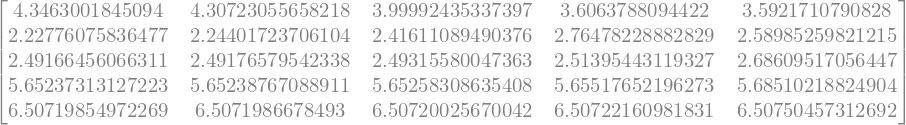

In [4]:
# Logarithmic Grid Search of lambda values
k = 3
nLambdas = 5
Lambdas = np.logspace(0, nLambdas, num=nLambdas, base=8)
numRuns = 2 # Num runs on each test (results averaged between this many)
RMSEs = zeros(nLambdas, nLambdas)
seeds = np.random.randint(10**10, size=numRuns)   # Use same random seeds for each k.
for i in range(nLambdas):
    for j in range(nLambdas):
        res = []
        for run in range(numRuns):
            rand.seed(int(seeds[run]))
            res.append(SolveRMSETikhonov(filename, pTrain, pTest, k=k, TikLambda1=Lambdas[i], TikLambda2=Lambdas[j], suppress=True))
        RMSEs[i,j] = np.mean(res)
RMSEs

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (25,) and arg 2 with shape (5, 5).

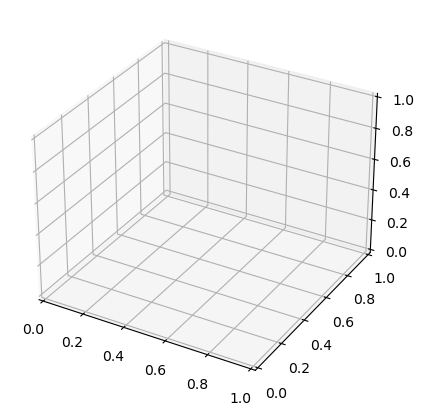

In [16]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111, projection='3d')
# PLot in 3D graph
_xx, _yy = np.meshgrid(Lambdas, Lambdas)
x, y = _xx.ravel(), _yy.ravel()
width = depth = 1
bottom = np.zeros_like(bottom)
ax1.bar3d(x, y, bottom, width, depth, list(RMSEs.reshape(nLambdas**2,1)), shade=True)

plt.show()

In [7]:
Numerical Optimisation of Params From Here?
Will be very different based on sample data.

SyntaxError: invalid syntax (443056260.py, line 2)

In [14]:
list(RMSEs.reshape(nLambdas**2,1))